# Training the model

The first step is to get a trained model. In this notebook we are going to train a simple classifier on the MNIST dataset using PyTorch.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Data

We start by loading the MNIST dataset using `torchvision.datasets`. We will use the training set for training the model and the test set for evaluation.

In [2]:
# from torchvision import datasets, transforms

# train_transform = transforms.Compose([
#     transforms.RandomAffine(degrees=(0,10), translate=(0.0, 0.1), scale=(0.7, 1.1), shear=(0,10)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,)),
#     transforms.Lambda(lambda x: x + 0.1 * torch.randn_like(x))
# ])
# test_transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

In [3]:
def make_spiral(n_samples_per_class=100, n_classes=3, noise=0.1):
    X = []
    y = []
    for class_id in range(n_classes):
        r = np.linspace(0.0, 1, n_samples_per_class)
        t = np.linspace(
            class_id * 4, (class_id + 1) * 4, n_samples_per_class
        ) + np.random.randn(n_samples_per_class) * noise

        x = r * np.sin(t)
        y_coord = r * np.cos(t)

        X.append(np.stack([x, y_coord], axis=1))
        y.append(np.full(n_samples_per_class, class_id))

    return np.vstack(X), np.concatenate(y)



from sklearn.model_selection import train_test_split

X, y = make_spiral(n_samples_per_class=400, n_classes=5, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
toy_dataset = torch.utils.data.TensorDataset(X, y)

train_dataset, test_dataset = train_test_split(toy_dataset, test_size=0.2, random_state=SEED, stratify=y)

# Save datasets
torch.save(train_dataset, 'data/datasets/train_spiral.pt')
torch.save(test_dataset, 'data/datasets/test_spiral.pt')

In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

## Neural Network Model

We define a simple feedforward neural network with two hidden layers

In [5]:
from preimage_sampling.models import SimpleClassifier
# from src.network import SimpleClassifier
# from src.network import SimpleCNNClassifier as SimpleClassifier

model = SimpleClassifier(num_classes=5).to(device)

# Print number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of trainable parameters: {num_params:e}')

Number of trainable parameters: 2.437000e+03


## Training

In [6]:
num_epochs = 300
initial_lr = 1e-2
final_lr = 1e-6

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=final_lr)

progress_bar = tqdm(range(num_epochs), desc='Training', unit='epoch')
train_losses, test_losses = [], []
for epoch in progress_bar:
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()   
    epoch_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    accuracy = 100. * correct / len(test_loader.dataset)
    progress_bar.set_postfix({'Train Loss': epoch_loss, 'Test Loss': epoch_test_loss, 'Test Acc': f'{accuracy:.2f}%'})
    scheduler.step()   
    

Training:   0%|          | 0/300 [00:00<?, ?epoch/s]

Final Training loss: 0.013470013407059014
Final Test loss: 0.03784634917974472


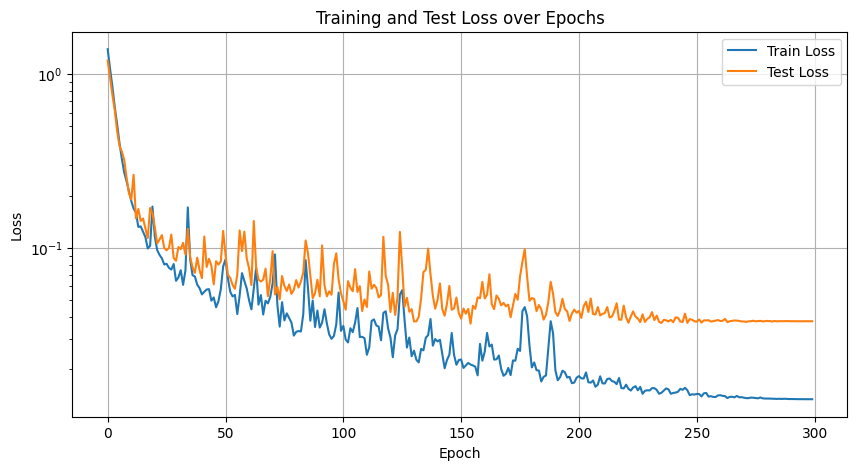

In [7]:
print("Final Training loss:", train_losses[-1])
print("Final Test loss:", test_losses[-1])

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

## Saving the Model

In [8]:
# Saving the model
torch.save(model.state_dict(), 'data/models/simple_classifier.pth')